In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [2]:
def linear_fit_plot(x, y):
    # TO RUN: import numpy as np, matplotlib.pyplot as plt and from scipy.stats import linregress
    result = linregress(x, y)
    m = result.slope
    c = result.intercept
    m_err = result.stderr
    c_err = result.intercept_stderr

    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = m * x_fit + c
    plt.plot(x_fit, y_fit, linestyle='--',label=f'Fitted equation: y = ({m:.3f} ± {m_err:.3f})x + ({c:.3f} ± {c_err:.3f})', color='red', linewidth=2)
    plt.legend()

EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) | Net Count Rate (cps)
    300 |           17 |               9 |                8 |              0.27
    330 |         2105 |              29 |             2076 |             69.20
    360 |         2570 |              39 |             2531 |             84.37
    390 |         2770 |              37 |             2733 |             91.10
    420 |         2686 |              39 |             2647 |             88.23
    450 |         2792 |              32 |             2760 |             92.00
    480 |         2805 |              38 |             2767 |             92.23
    510 |         2802 |              29 |             2773 |             92.43
    540 |         2910 |              38 |             2872 |             95.73
    570 |         2960 |              35 |             2925 |             97.50
    600 |         2865 |              37 |             2828 |             94.27
    630 |         2950 |            

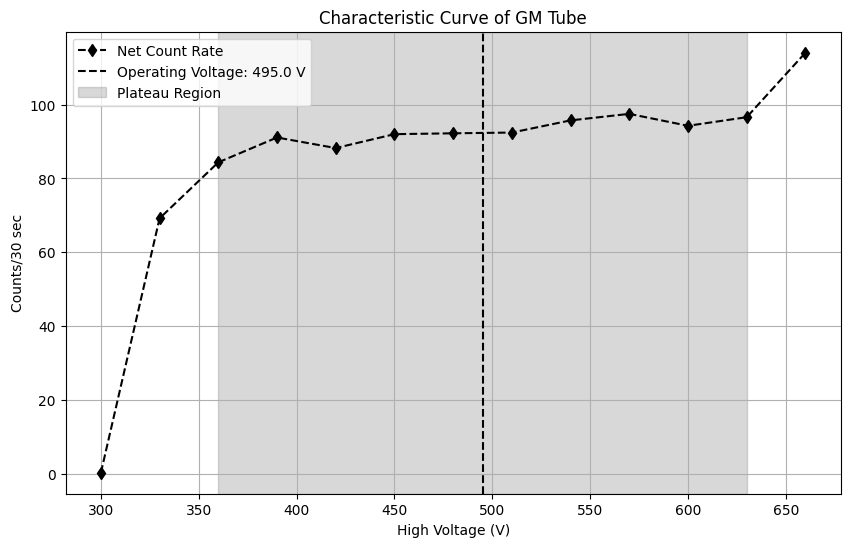

Plateau region: 360 V to 630 V
Operating voltage: 495.0 V
Plateau length: 270 V
Slope of plateau: 5.37%


In [3]:
# Geiger Müller-1 data analysis

# Characteristic curve of GM tube (determine plateau region and operating voltage)
EHT = np.array([300,330,360,390,420,450,480,510,540,570,600,630,660])  # High voltage in volts
Counts = np.array([17,2105,2570,2770,2686,2792,2805,2802,2910,2960,2865,2950,3472])  # in 30 sec
Background = np.array([9,29,39,37,39,32,38,29,38,35,37,52,50])  # Background count in 30 sec
Net_Counts = Counts - Background  # in 30 sec
Net_count_rate = Net_Counts / 30  # in counts per second

V1,V2 = 360, 630  # Plateau region voltage range
plateau_length = V2 - V1
V_op = (V1 + V2) / 2  # Operating voltage
Slope_plateau = ((2898 -2531)/2531)*(100/(630-360))*100  # in percentage
# Table of values
print("EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) | Net Count Rate (cps)")
for i in range(len(EHT)):
    print(f"{EHT[i]:7} | {Counts[i]:12} | {Background[i]:15} | {Net_Counts[i]:16} | {Net_count_rate[i]:17.2f}")

# Plotting the characteristic curve
plt.figure(figsize=(10, 6))
# fit plateau region with linear fit
# plateau_mask = (EHT >= V1) & (EHT <= V2)
# linear_fit_plot(EHT[plateau_mask], Net_count_rate[plateau_mask])
plt.plot(EHT, Net_count_rate, marker='d', linestyle='--', color='black', label='Net Count Rate')
plt.axvline(V_op, color='black', linestyle='--', label=f'Operating Voltage: {V_op:.1f} V')
plt.title('Characteristic Curve of GM Tube')
plt.xlabel('High Voltage (V)')
plt.ylabel('Counts/30 sec')
plt.axvspan(V1, V2, alpha=0.3, color='grey', label='Plateau Region')
plt.grid()
plt.legend()
plt.show()

# Summary of results
print(f"Plateau region: {V1} V to {V2} V")
print(f"Operating voltage: {V_op} V")
print(f"Plateau length: {plateau_length} V")
print(f"Slope of plateau: {Slope_plateau:.2f}%")



Distance (cm) | Counts (60s) | Net Counts (60s) | Net Counts/60sec | Product | Transformation (1/cm^2) | Log(Distance) | Log(Net Count Rate)
          2.0 |         4152 |           4082.8 |         68.04667 |  272.19 |                 0.25 |          0.69 |          4.22
          2.5 |         3373 |           3303.8 |         55.06333 |  344.15 |                 0.16 |          0.92 |          4.01
          3.0 |         2736 |           2666.8 |         44.44667 |  400.02 |                 0.11 |          1.10 |          3.79
          3.5 |         2235 |           2165.8 |         36.09667 |  442.18 |                 0.08 |          1.25 |          3.59
          4.0 |         1928 |           1858.8 |         30.98000 |  495.68 |                 0.06 |          1.39 |          3.43
          4.5 |         1504 |           1434.8 |         23.91333 |  484.25 |                 0.05 |          1.50 |          3.17
          5.0 |         1287 |           1217.8 |         20.29667

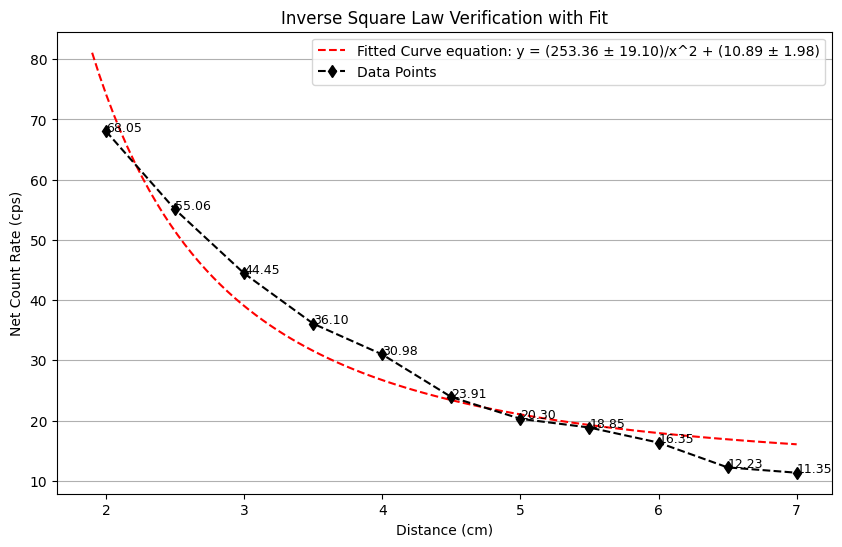

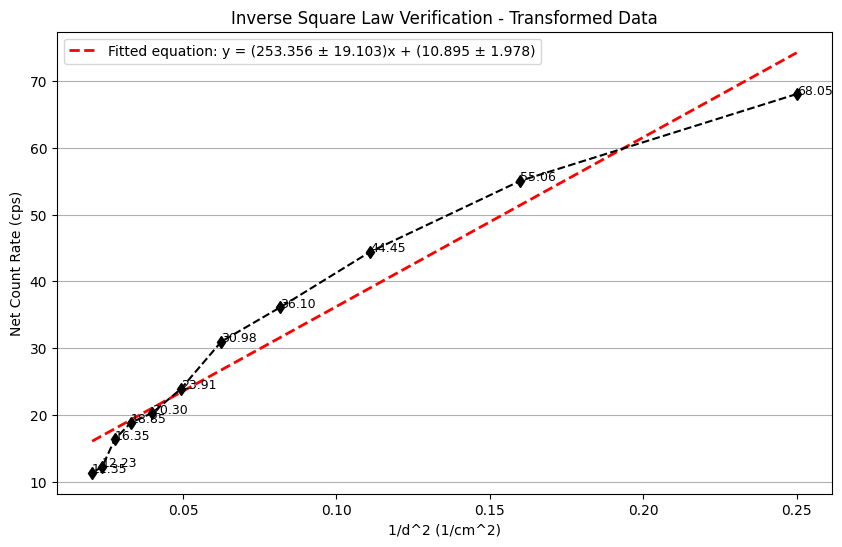

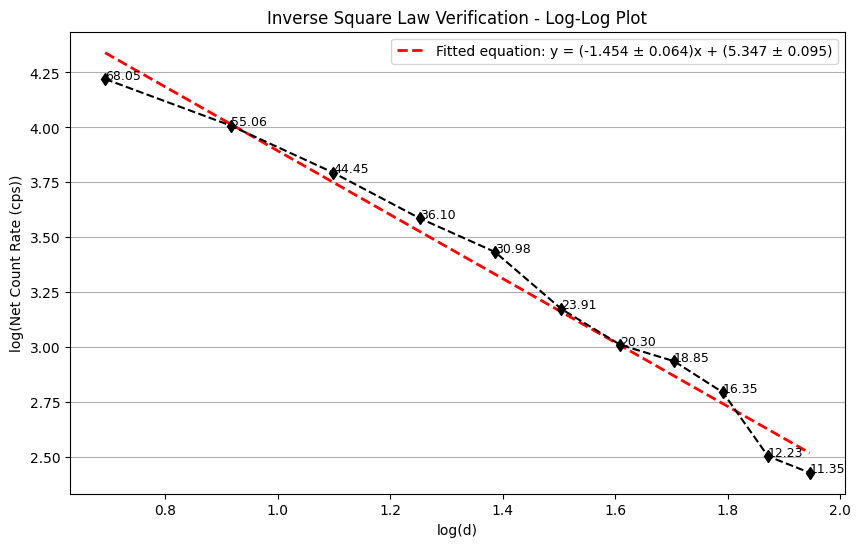

In [43]:
# Inverse square law verification (Cs-137 as a source)
dist = np.array([2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7])  # Distance in cm
Counts = np.array([4152,3373,2736,2235,1928,1504,1287,1200,1050,803,750])  # Counts in 60 sec at operating voltage = 495V
Back_count = np.array([59,76,61,77,73])  # Background count in 60 sec
Net_counts = Counts - Back_count.mean()  # Net counts in 60 sec
Net_count_rate = Net_counts / 60  # Net count rate in cps (R)
Product = Net_count_rate * dist**2  
Transformation = 1 / (dist)**2  # in 1/cm^2
ldis,lrate = np.log(dist), np.log(Net_count_rate)

# Table of values
print("\nDistance (cm) | Counts (60s) | Net Counts (60s) | Net Counts/60sec | Product | Transformation (1/cm^2) | Log(Distance) | Log(Net Count Rate)")
for i in range(len(dist)):
    print(f"{dist[i]:13} | {Counts[i]:12} | {Net_counts[i]:16} | {Net_count_rate[i]:16.5f} | {Product[i]:7.2f} | {Transformation[i]:20.2f} | {ldis[i]:13.2f} | {lrate[i]:13.2f}")
# Plotting the inverse square law verification with fit
def f(x, a, c):
    return a/x**2 + c
popt, pcov = curve_fit(f, dist, Net_count_rate)
a, c = popt
aerr, cerr = np.sqrt(np.diag(pcov))
plt.figure(figsize=(10, 6))
x_fit = np.linspace(1.9, 7, 100)
y_fit = f(x_fit, *popt)
plt.plot(x_fit, y_fit, linestyle = '--',label=f'Fitted Curve equation: y = ({a:.2f} ± {aerr:.2f})/x^2 + ({c:.2f} ± {cerr:.2f})', color='red')
for i in range(len(dist)):
    plt.text(dist[i], Net_count_rate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')
plt.plot(dist, Net_count_rate, marker='d', linestyle='--', color='black', label='Data Points')
plt.title('Inverse Square Law Verification with Fit')
plt.xlabel('Distance (cm)')
plt.ylabel('Net Count Rate (cps)')
plt.grid(True,axis='y')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i in range(len(Transformation)):
    plt.text(Transformation[i], Net_count_rate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')

#fitting R vs 1/d^2 
linear_fit_plot(Transformation, Net_count_rate)
plt.plot(Transformation,Net_count_rate, marker='d', linestyle='--', color='black')
plt.title('Inverse Square Law Verification - Transformed Data')
plt.xlabel('1/d^2 (1/cm^2)')
plt.ylabel('Net Count Rate (cps)')
plt.grid(True,axis='y') 
plt.show()

plt.figure(figsize=(10, 6))
for i in range(len(dist)):
    plt.text(ldis[i], lrate[i], f"{Net_count_rate[i]:.2f}", fontsize=9, ha='left')
linear_fit_plot(ldis, lrate)
plt.plot(ldis, lrate, marker='d', linestyle='--', color='black')
plt.title('Inverse Square Law Verification - Log-Log Plot')
plt.xlabel('log(d)')
plt.ylabel('log(Net Count Rate (cps))')
plt.grid(True,axis='y')
plt.show()


In [58]:
# efficiency calculation for gamma source(Cs-137) and beta source(Th-204)
d = 1.5 # in cm (aperture diameter)
# For Cs-137 (gamma source)
A_g = 79 # activity in KBq (may 2016)
lambda_g = 0.02297 # decay constant for Cs-137
t = 2025 - 2016 + 11/12  # time in years from may 2016 to april 2026
A_g = 79*np.exp(-lambda_g * t) # present activity in KBq
# print('time =', t, 'years'+'A_g =', A_g, 'KBq')
Dist_gamma = 10  # Distance in cm
Nb = [102,100,113] # Background counts in 60 sec
Ns = [759,683,728] # Source counts in 60 sec
Net_counts_gamma_rate = (np.array(Ns) - np.array(Nb)) / 60  # Net count rate in cps
# print('Net count rate for gamma source =', Net_counts_gamma_rate, 'cps')
R = A_g*1000*d**2/(16*Dist_gamma**2) # fraction of emitted particles reaching the detector
Efficiency_gamma = (Net_counts_gamma_rate * 100) / R  # Efficiency % calculation

# For Th-204 (beta source)
A_b = 11 # activity in KBq
lambda_b = 0.18337 # decay constant for Th-204 (assuming same as Cs-137 for this example)
A_b = 11*np.exp(-lambda_b * t) # present activity in KBq
Dist_beta = 2  # Distance in cm
Nb_beta = [121,108,107]  # Background counts in 100 sec 
Ns_beta = [1241,1256,1290]  # Source counts in 100 sec
Net_counts_beta_rate = (np.array(Ns_beta) - np.array(Nb_beta)) / 100  # Net count rate in cps
R_beta = A_b*1000*d**2/(16*Dist_beta**2) # fraction of emitted particles reaching the detector
Efficiency_beta = (Net_counts_beta_rate * 100) / R_beta  # Efficiency % calculation
# Table of efficiency results
print("            Gamma Source        |               Beta Source")
print(" Net Counts rate  | Efficiency % | Net Counts rate  | Efficiency %")
for i in range(len(Net_counts_gamma_rate)):
    print(f" {Net_counts_gamma_rate[i]:16.5f} | {Efficiency_gamma[i]:10.5f} || {Net_counts_beta_rate[i]:16.5f} | {Efficiency_beta[i]:10.5f}")

            Gamma Source        |               Beta Source
 Net Counts rate  | Efficiency % | Net Counts rate  | Efficiency %
         10.95000 |   12.37800 ||         11.20000 |   17.84646
          9.71667 |   10.98383 ||         11.48000 |   18.29263
         10.25000 |   11.58672 ||         11.83000 |   18.85033



Mean Value | Ni - mean | (Ni - mean)^2
     69.00 |      2.00 |           4.00
     69.00 |     -9.00 |          81.00
     69.00 |      8.00 |          64.00
     69.00 |    -11.00 |         121.00
     69.00 |      3.00 |           9.00
     69.00 |    -13.00 |         169.00
     69.00 |      0.00 |           0.00
     69.00 |      6.00 |          36.00
     69.00 |      1.00 |           1.00
     69.00 |      1.00 |           1.00
     69.00 |      3.00 |           9.00
     69.00 |     -4.00 |          16.00
     69.00 |    -12.00 |         144.00
     69.00 |     -5.00 |          25.00
     69.00 |     -8.00 |          64.00
     69.00 |     -6.00 |          36.00
     69.00 |      3.00 |           9.00
     69.00 |      9.00 |          81.00
     69.00 |     10.00 |         100.00
     69.00 |     14.00 |         196.00
     69.00 |      4.00 |          16.00
     69.00 |     21.00 |         441.00
     69.00 |     -7.00 |          49.00
     69.00 |     13.00 |         169.00


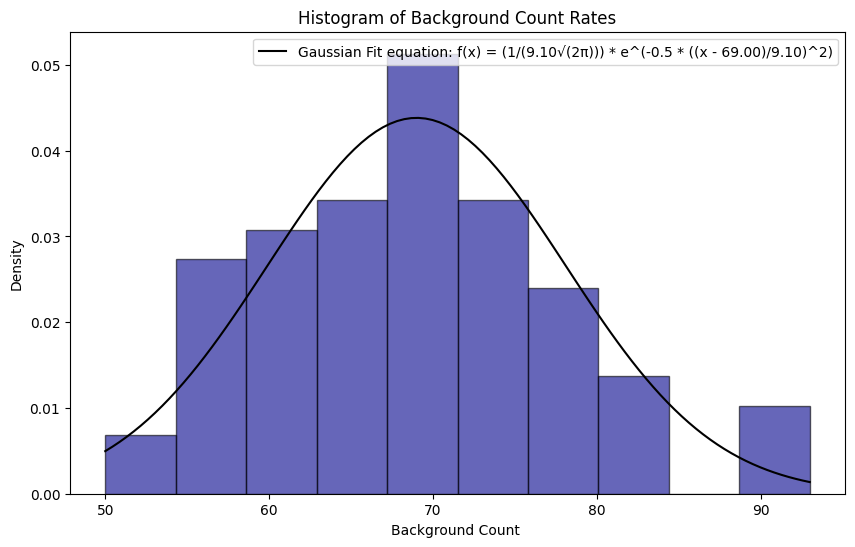

Mean count for beta source = 314.64

Count | sd_beta | Ni - mean | (Ni - mean)/sd_beta | (Ni - mean)/sd_beta (rounded)
  323 |    17.74 |      8.36 |             0.47 |             0.50
  322 |    17.74 |      7.36 |             0.41 |             0.50
  319 |    17.74 |      4.36 |             0.25 |             0.00
  352 |    17.74 |     37.36 |             2.11 |             2.00
  334 |    17.74 |     19.36 |             1.09 |             1.00
  297 |    17.74 |    -17.64 |            -0.99 |            -1.00
  330 |    17.74 |     15.36 |             0.87 |             1.00
  319 |    17.74 |      4.36 |             0.25 |             0.00
  327 |    17.74 |     12.36 |             0.70 |             0.50
  287 |    17.74 |    -27.64 |            -1.56 |            -2.00
  287 |    17.74 |    -27.64 |            -1.56 |            -2.00
  310 |    17.74 |     -4.64 |            -0.26 |            -0.50
  327 |    17.74 |     12.36 |             0.70 |             0.50
  348 |   

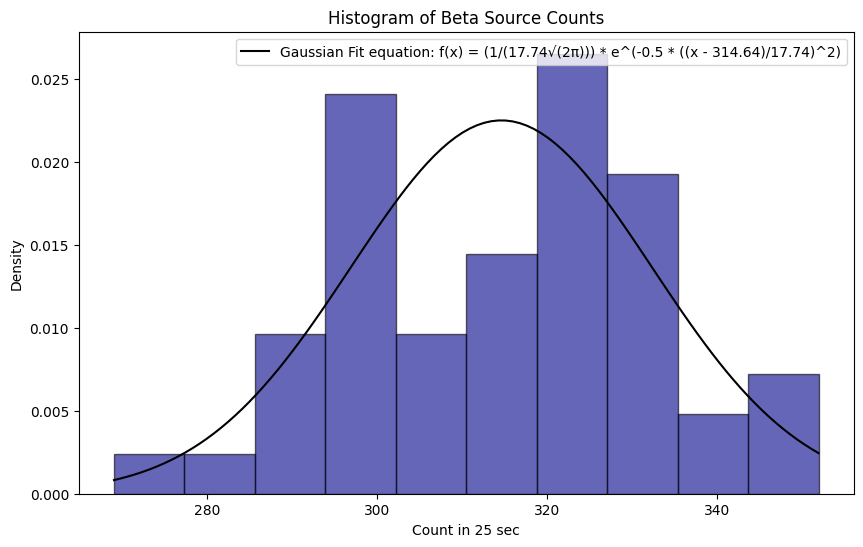

Mean Value | Variance | Standard Deviation
314.64       | 314.64     | 17.74


In [59]:
# Statistical error analysis for gamma source
bg_counts = [
    71, 60, 77, 58, 72, 56, 69, 75, 70, 70, 72, 65, 57, 64, 61, 63, 72, 78,
    79, 83, 73, 90, 62, 82, 67, 68, 82, 93, 74, 75, 80, 57, 69, 93, 77, 69, 62,
    65, 65, 72, 66, 56, 70, 80, 62, 59, 62, 63, 58, 77, 71, 71, 69, 68, 62, 67,
    64, 52, 60, 81, 50, 70, 57, 72, 72, 69, 57, 68 ]  # Background counts in 60 sec

# statistical results
Mean_value = round(np.mean(bg_counts),0)  # Mean background count rate in cps
dev = np.array(bg_counts) - Mean_value # Deviation from average
Variance = np.sum(dev**2) / len(bg_counts) # Sample variance
sd_ = np.sqrt(Variance)  # Standard deviation

# Table of statistical analysis results
print("\nMean Value | Ni - mean | (Ni - mean)^2")
for i in range(len(bg_counts)):
    print(f"{Mean_value:10.2f} | {dev[i]:9.2f} | {(dev[i])**2:14.2f}")
print("Mean Value | Variance | Standard Deviation")
print(f"{Mean_value:.2f}       | {Variance:.2f}     | {sd_:.2f}") 

# plot for background count rate hist and fit with gaussian
plt.figure(figsize=(10, 6))
plt.hist(bg_counts, bins=10, density=True, alpha=0.6, color='darkblue',edgecolor='black')
def gaussian(x, mu, sigma):
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
x = np.linspace(min(bg_counts), max(bg_counts), 100)
y = gaussian(x, Mean_value, sd_)
plt.plot(x, y, color='black', label=f'Gaussian Fit equation: f(x) = (1/({sd_:.2f}√(2π))) * e^(-0.5 * ((x - {Mean_value:.2f})/{sd_:.2f})^2)') 
plt.title('Histogram of Background Count Rates')
plt.xlabel('Background Count ')
plt.ylabel('Density')
plt.legend()
plt.grid(False)
plt.show()

# with beta source 
counts_beta = [
    323, 322, 319, 352, 334, 297, 330, 319, 327, 287,
    287, 310, 327, 348, 311, 299, 292, 329, 269, 332,
    337, 323, 300, 305, 344, 292, 334, 299, 322, 316,
    315, 294, 339, 317, 318,
    308, 314, 319, 330, 322, 296, 301, 300, 295, 328,
    301, 332, 284, 325, 308 ] # in 25 sec
mean = np.mean(counts_beta)  # Mean count rate
print('Mean count for beta source =', mean,)
dev_beta = np.array(counts_beta) - mean  # Deviation from mean
sd_beta = np.sqrt(mean)  # Standard deviation (Poisson distribution)
z_scores = dev_beta / sd_beta  # Standard score (z-score) for each count
z_scores_r = []
for z in z_scores:
    if abs(z)>= 0 and abs(z)<0.25:
        z_scores_r.append(0)
    elif abs(z)>=0.25 and abs(z)< 0.75:
        if z > 0:
            z_scores_r.append(0.5)
        else:
            z_scores_r.append(-0.5)
    elif abs(z)>=0.75 and abs(z)< 1.25:
        if z > 0:
            z_scores_r.append(1)
        else:
            z_scores_r.append(-1)
    elif abs(z)>=1.25 and abs(z)<2.25:
        if z > 0:
            z_scores_r.append(2)
        else:            
            z_scores_r.append(-2)
    else:
        if z > 0:
            z_scores_r.append(3)
        else:
            z_scores_r.append(-3)
        
print("\nCount | sd_beta | Ni - mean | (Ni - mean)/sd_beta | (Ni - mean)/sd_beta (rounded)")
for i in range(len(counts_beta)):
    print(f"{counts_beta[i]:5} | {sd_beta:8.2f} | {dev_beta[i]:9.2f} | {z_scores[i]:16.2f} | {z_scores_r[i]:16.2f}")

plt.figure(figsize=(10, 6))
# fit with gaussian
x_fit = np.linspace(min(counts_beta), max(counts_beta), 100)
def gaussian_beta(x, mu, sigma):
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
y_fit = gaussian_beta(x_fit, mean, sd_beta)
plt.plot(x_fit, y_fit, color='black', label=f'Gaussian Fit equation: f(x) = (1/({sd_beta:.2f}√(2π))) * e^(-0.5 * ((x - {mean:.2f})/{sd_beta:.2f})^2)')
plt.hist(counts_beta, bins=10, density=True, alpha=0.6, color='darkblue',edgecolor='black')
plt.title('Histogram of Beta Source Counts')
plt.xlabel('Count in 25 sec')
plt.ylabel('Density')
plt.legend()
plt.grid(False)
plt.show()

print("Mean Value | Variance | Standard Deviation")
print(f"{mean:.2f}       | {sd_beta**2:.2f}     | {sd_beta:.2f}") 


EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) | Net Count Rate (cps)
    330 |            0 |               0 |                0 |              0.00
    360 |         1579 |              29 |             1550 |             51.67
    390 |         1688 |              37 |             1651 |             55.03
    420 |         1733 |              37 |             1696 |             56.53
    450 |         1636 |              39 |             1597 |             53.23
    480 |         1646 |              38 |             1608 |             53.60
    510 |         1653 |              26 |             1627 |             54.23
    540 |         1819 |              35 |             1784 |             59.47
    571 |         1763 |              31 |             1732 |             57.73
    600 |         1726 |              36 |             1690 |             56.33
    630 |         3417 |              76 |             3341 |            111.37


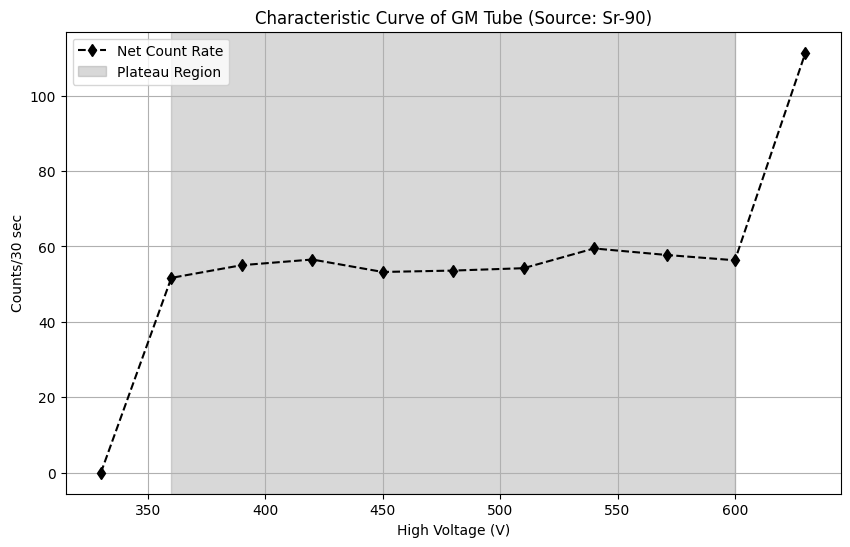

Plateau region: 360 V to 600 V
Operating voltage: 480.0 V
Plateau length: 240 V
Slope of plateau: 3.76%


In [7]:
# GM-2 Analysis
#  Characteristic curve of GM tube (determine plateau region and operating voltage)
EHT = np.array([330,360,390,420,450,480,510,540,571,600,630])  # High voltage in volts
Counts = np.array([0,1579,1688,1733,1636,1646,1653,1819,1763,1726,3417])  # in 30 sec
Background = np.array([0,29,37,37,39,38,26,35,31,36,76])  # Background count in 30 sec
Net_Counts = Counts - Background  # in 30 sec
Net_count_rate = Net_Counts / 30  # in counts per second

V1,V2 = 360, 600  # Plateau region voltage range
plateau_length = V2 - V1
V_op = (V1 + V2) / 2  # Operating voltage
Slope_plateau = ((1690 -1550)/1550)*(100/(600-360))*100  # in percentage
# Table of values
print("EHT (V) | Counts (30s) | Background (30s) | Net Counts (30s) | Net Count Rate (cps)")
for i in range(len(EHT)):
    print(f"{EHT[i]:7} | {Counts[i]:12} | {Background[i]:15} | {Net_Counts[i]:16} | {Net_count_rate[i]:17.2f}")

# Plotting the characteristic curve
plt.figure(figsize=(10, 6))
plt.plot(EHT, Net_count_rate, marker='d', linestyle='--', color='black', label='Net Count Rate')
plt.title('Characteristic Curve of GM Tube (Source: Sr-90)')
plt.xlabel('High Voltage (V)')
plt.ylabel('Counts/30 sec')
plt.axvspan(V1, V2, alpha=0.3, color='grey', label='Plateau Region')
plt.grid()
plt.legend()
plt.show()

# Summary of results
print(f"Plateau region: {V1} V to {V2} V")
print(f"Operating voltage: {V_op} V")
print(f"Plateau length: {plateau_length} V")
print(f"Slope of plateau: {Slope_plateau:.2f}%")

Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)
          0.00 |                0.00 |         6713 |          6533.00 |             36.29
          0.05 |               13.55 |         4782 |          4602.00 |             25.57
          0.10 |               27.10 |         3959 |          3779.00 |             20.99
          0.15 |               40.65 |         3475 |          3295.00 |             18.31
          0.20 |               54.20 |         2930 |          2750.00 |             15.28
          0.25 |               67.75 |         2649 |          2469.00 |             13.72
          0.30 |               81.30 |         2401 |          2221.00 |             12.34
          0.35 |               94.85 |         2153 |          1973.00 |             10.96


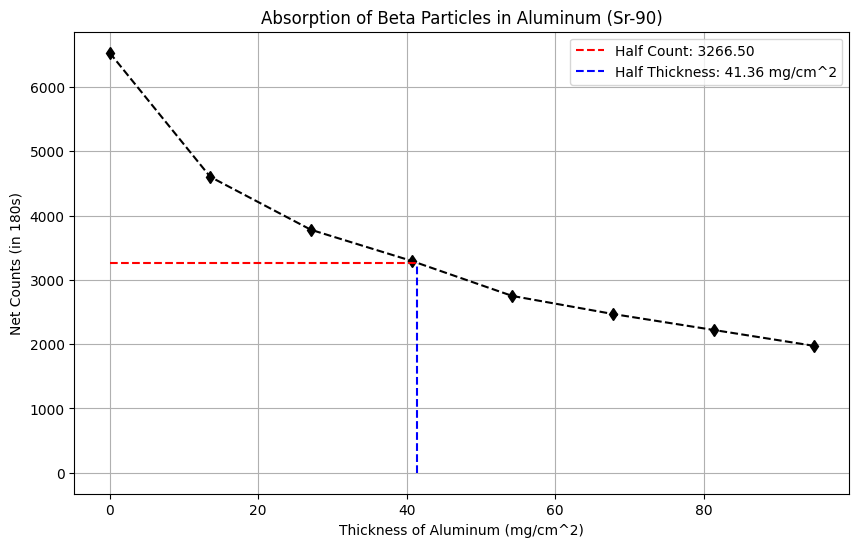


Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)
          0.00 |                0.00 |         1097 |           917.00 |              5.09
          0.05 |               13.55 |          703 |           523.00 |              2.91
          0.10 |               27.10 |          543 |           363.00 |              2.02
          0.15 |               40.65 |          440 |           260.00 |              1.44
          0.20 |               54.20 |          335 |           155.00 |              0.86
          0.25 |               67.75 |          294 |           114.00 |              0.63
          0.30 |               81.30 |          298 |           118.00 |              0.66


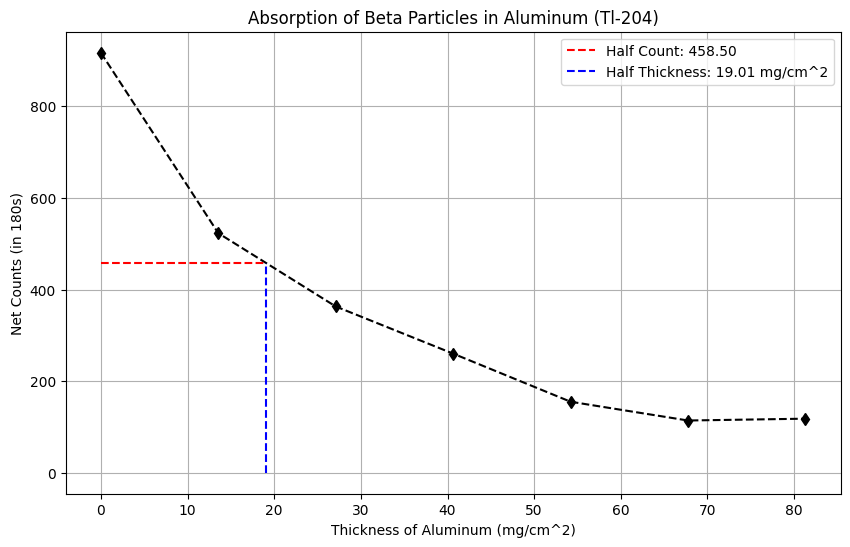

Range of beta particles in aluminum: 0.66844 g/cm^2
End point energy of beta particles: 1.46 MeV


In [40]:
# absorption of beta particles in aluminum (half thickness method) Sr-90
thickness = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3,0.35])  # Thickness in mm
thick2 = thickness* 2.71*100  # in mg/cm^2 (density of aluminum = 2.71 g/cm^3)
counts_beta = np.array([6713,4782,3959,3475,2930,2649,2401,2153])  # Counts in 180 sec for each thickness
back = np.array([51,77,63,57,68])  # Background counts in 60 sec
back_rate = int(np.mean(back) / 60)  # Background count rate in cps
Net_counts_beta = counts_beta - back_rate * 180  # Net counts in 180 sec
Net_count_rate_beta = Net_counts_beta / 180  # Net count rate in cps

# Table of beta absorption analysis
print("Thickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)")
for i in range(len(thickness)):
    print(f"{thickness[i]:14.2f} | {thick2[i]:19.2f} | {counts_beta[i]:12} | {Net_counts_beta[i]:16.2f} | {Net_count_rate_beta[i]:17.2f}")

half_count = Net_counts_beta[0] / 2  # Half of the initial count for Sr-90
t_half_ = ((54.2-40.65)/(2750 - 3295))*(half_count-3295) + 40.65
# Plotting the absorption curve
plt.figure(figsize=(10, 6))
plt.plot(thick2, Net_counts_beta, marker='d', linestyle='--', color='black')
plt.hlines(half_count, xmin=0, xmax=t_half_, color='r', linestyle='--', label=f'Half Count: {half_count:.2f}')
plt.vlines(t_half_, ymin=0, ymax=half_count, color='b', linestyle='--', label=f'Half Thickness: {t_half_:.2f} mg/cm^2')
plt.title('Absorption of Beta Particles in Aluminum (Sr-90)')
plt.xlabel('Thickness of Aluminum (mg/cm^2)')
plt.ylabel('Net Counts (in 180s)')
plt.legend()
plt.grid()
plt.show()

# absorption of beta particles in aluminum (half thickness method) Tl-204
thickness_tl = np.array([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3])  # Thickness in mm
thick2_tl = thickness_tl * 2.71*100  # in mg/cm^2 (density of aluminum = 2.71 g/cm^3)
counts_tl = np.array([1097,703,543,440,335,294,298])  # Counts in 180 sec for each thickness
back_tl = np.array([73,67,51,71,67])  # Background counts in 60 sec
back_rate_tl = int(np.mean(back_tl) / 60)  # Background count rate in cps
Net_counts_tl = counts_tl - back_rate_tl * 180  # Net counts in 180 sec

Net_count_rate_tl = Net_counts_tl / 180  # Net count rate in cps
 
# Table of beta absorption analysis for Tl-204
print("\nThickness (mm) | Thickness (mg/cm^2) | Counts (180s) | Net Counts (180s) | Net Count Rate (cps)")
for i in range(len(thickness_tl)):
    print(f"{thickness_tl[i]:14.2f} | {thick2_tl[i]:19.2f} | {counts_tl[i]:12} | {Net_counts_tl[i]:16.2f} | {Net_count_rate_tl[i]:17.2f}")
half_count_tl = Net_counts_tl[0] / 2  # Half of the initial count for Tl-204
t_half = ((27.1-13.55)/(363-523))*(half_count_tl-523) + 13.55
# Plotting the absorption curve for Tl-204
plt.figure(figsize=(10, 6))
plt.plot(thick2_tl, Net_counts_tl, marker='d', linestyle='--', color='black')
plt.hlines(half_count_tl, xmin=0, xmax=t_half, color='r', linestyle='--', label=f'Half Count: {half_count_tl:.2f}')
plt.vlines(t_half, ymin=0, ymax=half_count_tl, color='b', linestyle='--', label=f'Half Thickness: {t_half:.2f} mg/cm^2')
plt.title('Absorption of Beta Particles in Aluminum (Tl-204)')
plt.xlabel('Thickness of Aluminum (mg/cm^2)')
plt.ylabel('Net Counts (in 180s)')
plt.grid()
plt.legend()
plt.show()

# Claculation of range of beta particles
R_tl = 0.30728 # in g/cm^2 
R_beta = R_tl * (t_half_ / t_half)  # Range of beta particles in g/cm^2
print(f"Range of beta particles in aluminum: {R_beta:.5f} g/cm^2")
End_point_energy = (R_beta +0.09)/0.52 # in MeV (using empirical relation for beta particles)
print(f"End point energy of beta particles: {End_point_energy:.2f} MeV")

In [ ]:
# Backscattering of beta particles from aluminum